# Model explanation

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Change this path
csv_path = Path("../model/detect/train/results.csv")

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

display(df.head())
print(df.columns)

## 1. Loss curve
The training and validation losses show a consistent decreasing trend, indicating successful convergence of the model during optimization. A rapid reduction is observed during the early epochs, followed by a progressive stabilization as the model approaches a local optimum. 

Validation losses remain slightly lower than training losses throughout training. The relatively lower validation losses may be influenced by the smaller size of the validation set, which can reduce data variability and make the validation samples comparatively easier than the training distribution. The small gap between both curves and their similar evolution suggest good generalization performance, with no clear evidence of overfitting.

In [ ]:
import matplotlib.pyplot as plt

loss_types = ["box_loss", "cls_loss", "dfl_loss"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, loss in zip(axes, loss_types):
    
    train_col = f"train/{loss}"
    val_col = f"val/{loss}"

    # Training en noir
    if train_col in df.columns:
        ax.plot(
            df["epoch"],
            df[train_col],
            color="black",
            linewidth=2.5,
            label="Training"
        )

    # Validation en gris
    if val_col in df.columns:
        ax.plot(
            df["epoch"],
            df[val_col],
            color="gray",
            linewidth=2.5,
            linestyle="--",
            label="Validation"
        )

    ax.set_title(loss.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

plt.suptitle(
    "YOLOv8 Training vs Validation Losses",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

## 2. Precision, recall, mAP

In [ ]:
import matplotlib.pyplot as plt

metrics = {
    "metrics/precision(B)": "Precision",
    "metrics/recall(B)": "Recall",
    "metrics/mAP50(B)": "mAP50",
    "metrics/mAP50-95(B)": "mAP50:95"
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics.items()):

    if col in df.columns:

        ax.plot(
            df["epoch"],
            df[col],
            color="black",
            linewidth=2.5
        )

        # light area under curve
        ax.fill_between(
            df["epoch"],
            df[col],
            alpha=0.15,
            color="black"
        )

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")

    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle(
    "YOLOv8 Detection Metrics During Training",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

The detection metrics show rapid convergence during the first epochs, followed by a stabilization phase. Precision, recall, and mAP50 quickly approach values close to 1, indicating that the model rapidly learns to correctly identify and localize objects. The mAP50:95 metric increases more gradually, as it evaluates localization quality under stricter IoU thresholds. The smooth saturation of all metrics and the absence of performance degradation suggest stable training and good generalization capability.

## 3. Prediction on test images
Before Launching this cell, please make sure to have run the main.py to generate the /runs/detect/predict folder

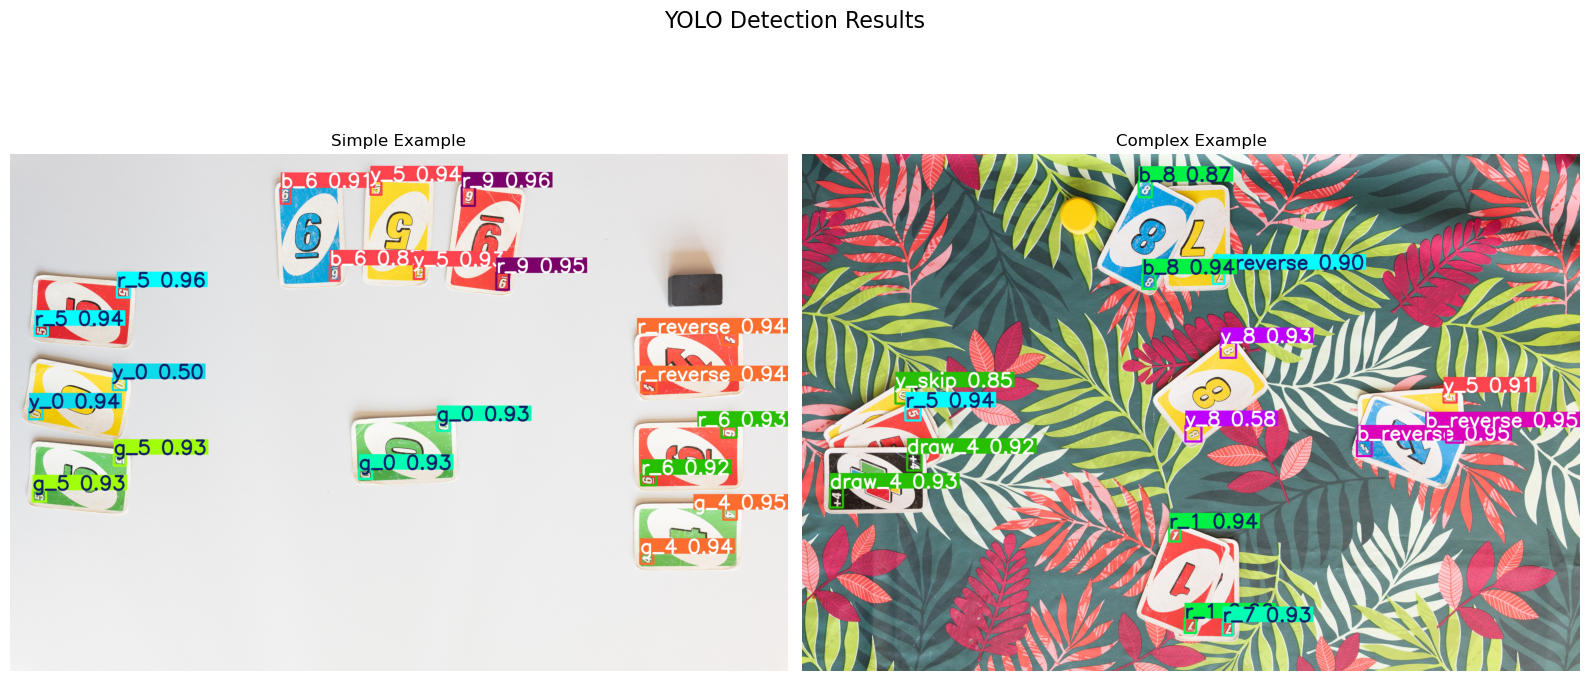

In [24]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

predict_folder = Path("../runs/detect/predict")

# Choose images
simple_file = "L1000793.jpg"
complex_file = "L1001003.jpg"

img1 = Image.open(predict_folder / simple_file)
img2 = Image.open(predict_folder / complex_file)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Simple example
axes[0].imshow(img1)
axes[0].set_title("Simple Example")
axes[0].axis("off")

# More difficult example
axes[1].imshow(img2)
axes[1].set_title("Complex Example")
axes[1].axis("off")

plt.suptitle("YOLO Detection Results", fontsize=16)

plt.tight_layout()
plt.show()

The figure shows YOLO detection results on an unseen images from the original Kaggle dataset that was not used during training. The model successfully detects and localizes UNO cards under different orientations and positions, with most predictions associated with high confidence scores (>0.9), indicating strong prediction certainty. Correct detections are obtained even for partially rotated and partially occluded cards. Failure cases and prediction limitations are discussed separately.

## 4. Feature-map visualizations

In [ ]:
from pathlib import Path
from ultralytics import YOLO

model_path = Path("../model/best.pt")
model = YOLO(model_path)

# Choose images
path_to_file = Path("../runs/detect/predict/L1000793.jpg")

model.predict(
    source=path_to_file,
    imgsz=960,
    conf=0.25,
    visualize=True
)

NameError: name 'path_to_file' is not defined